# 04 · label + baseline  (go / no-go)

minimal signal check before we invest in features. build the peer-relative tercile label, three crude
trailing features, a chronological train/test split, and a plain xgboost. question: **does anything beat
the 33% random-guess floor?** if not, we pivot the label to a 21-day horizon (5d is near the noise floor).

not fancy on purpose. no subcategory peers, no sentiment, no feature menu, no tuning - those come *after*
this proves signal exists.

In [1]:
import yaml, pathlib
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, classification_report
from xgboost import XGBClassifier
sns.set_theme(style='whitegrid')

ROOT = pathlib.Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
cfg = yaml.safe_load(open(ROOT / 'config.yaml', encoding='utf-8'))
RAW = ROOT / cfg['paths']['raw']
prices   = pd.read_parquet(RAW / 'prices.parquet'); prices.index.name = 'date'; prices.columns.name = 'ticker'
metadata = pd.read_parquet(RAW / 'metadata.parquet')
H = cfg['labels']['horizon']; MIN = cfg['labels']['min_group']
print('raw panel:', prices.shape, '| horizon', H, 'days')

raw panel: (2512, 2037) | horizon 5 days


## clean the panel

drop leveraged/inverse and bad-tick funds. **keep delisted funds** up to their last valid date - a
dead etf is a legit training row until it dies; dropping them makes the backtest look better than
reality (survivorship). also drop tiny categories (< min_group) and the 'Uncategorized' grab-bag
(ranking within it isn't 'beating peers').

In [2]:
bad = metadata['is_leveraged'].fillna(False) | metadata['bad_ticks'].fillna(False)   # NOTE: not is_delisted
prices = prices.drop(columns=[t for t in metadata.index[bad] if t in prices.columns])
cat = metadata['category'].reindex(prices.columns)

sizes = cat.value_counts()
keep_cats = sizes[(sizes >= MIN) & (sizes.index != 'Uncategorized')].index
keep = cat[cat.isin(keep_cats)].index
prices = prices[keep]; cat = cat[keep]
print('kept', prices.shape[1], 'funds in', len(keep_cats), 'categories (delisted retained)')

kept 1628 funds in 35 categories (delisted retained)


## label — tercile of excess forward-5d return

for each etf each day t: forward-5d return, minus its **category mean** forward-5d return = excess.
then within each (category, day) rank funds into terciles: 0 Underperform / 1 Neutral / 2 Outperform.
ranking within category+day auto-balances the classes and locks the target to 'beat your peers'.
rows where t+5 runs off the end get no label and drop out.

In [3]:
fwd = prices.shift(-H) / prices - 1.0                     # forward 5d return (uses the future - thats the LABEL, allowed)
cat_mean_fwd = fwd.T.groupby(cat).transform('mean').T     # category MEAN forward return, same window
excess = fwd - cat_mean_fwd

# rank into terciles within each (date, category)
ex = excess.stack().rename('excess').reset_index()        # cols: date, ticker, excess (NaN fwd rows dropped)
ex['cat'] = ex['ticker'].map(cat)
g = ex.groupby(['date', 'cat'])['excess']
pct = g.rank(pct=True)                                    # 0..1 rank of excess within its peer group that day
size = g.transform('size')
lab = np.select([pct <= 1/3, pct <= 2/3], [0, 1], default=2).astype(float)
lab[size < MIN] = np.nan                                  # need >= MIN peers that day for a real tercile
ex['label'] = lab
label = ex.set_index(['date', 'ticker'])['label']
print('label rows:', int(label.notna().sum()))
print('class balance:', label.value_counts(normalize=True).round(3).to_dict(), '(terciles -> ~1/3 each)')

label rows: 3447076
class balance: {2.0: 0.341, 1.0: 0.333, 0.0: 0.326} (terciles -> ~1/3 each)


## features — three crude, no lookahead

all use only data up to and including t. note the relative-strength feature uses the **trailing**
category mean (past), unlike the label which uses the forward window - that asymmetry is correct.

In [4]:
rets = prices.pct_change(fill_method=None)
ret_5d  = prices / prices.shift(H) - 1.0                  # trailing 5d return (t vs t-5)
vol_21d = rets.rolling(21).std()                          # 21d realized vol, data up to t
cat_mean_ret5 = ret_5d.T.groupby(cat).transform('mean').T # TRAILING category mean (past data)
rel_str_5d = ret_5d - cat_mean_ret5                       # relative strength vs peers, trailing

features = pd.concat({'ret_5d': ret_5d.stack(), 'vol_21d': vol_21d.stack(),
                      'rel_str_5d': rel_str_5d.stack()}, axis=1)
features.index.names = ['date', 'ticker']

data = features.join(label).dropna()
data['label'] = data['label'].astype(int)
print('modeling rows:', data.shape, '|', data.index.get_level_values('date').min().date(),
      '->', data.index.get_level_values('date').max().date())
data.head()

modeling rows: (3410713, 4) | 2016-08-09 -> 2026-06-30


ret_5d   vol_21d  rel_str_5d  label
date       ticker                                       
2016-08-09 AADR   -0.002217  0.008616   -0.031903      2
           AAXJ    0.027022  0.006356   -0.002664      1
           ACWF   -0.010930  0.008455   -0.020683      2
           ACWI    0.018339  0.004166    0.008586      2
           ACWX    0.022161  0.005959    0.012408      2

## time-based split  (no shuffle!)

train on older dates, test on newer - a random split would leak the future. **purged**: any train
row whose forward-5d label window pokes past the test start is dropped. `purge_cutoff` finds the
last trading day whose `[t, t+H]` label window ends on or before the test start, so the kept train
set shares zero forward-return days with the test set.

In [5]:
def purge_cutoff(trading_index, test_start, h):
    """Last train date whose forward-h label window ends on/before test_start.
    trading_index: the price panel's DatetimeIndex (actual trading days)."""
    pos = trading_index.searchsorted(pd.Timestamp(test_start))
    return trading_index[max(pos - h, 0)]

In [6]:
split = pd.Timestamp(cfg['split']['date'])
d = data.reset_index()
Xcols = ['ret_5d', 'vol_21d', 'rel_str_5d']
test = d[d['date'] > split]
first_test = test['date'].min()
cut = purge_cutoff(prices.index, first_test, H)
train = d[d['date'] <= cut]                     # purged: drop rows whose label window pokes into test
Xtr, ytr = train[Xcols], train['label']
Xte, yte = test[Xcols], test['label']
print(f'train {Xtr.shape}  {train["date"].min().date()} -> {train["date"].max().date()}  (purge cutoff {cut.date()}, nominal split {split.date()})')
print(f'test  {Xte.shape}  {test["date"].min().date()} -> {test["date"].max().date()}')
print('train balance', ytr.value_counts(normalize=True).round(2).to_dict(),
      '| test balance', yte.value_counts(normalize=True).round(2).to_dict())

train (2545252, 3)  2016-08-09 -> 2023-12-22  (purge cutoff 2023-12-22, nominal split 2023-12-31)
test  (859695, 3)  2024-01-02 -> 2026-06-30
train balance {2: 0.34, 1: 0.33, 0: 0.33} | test balance {2: 0.34, 1: 0.33, 0: 0.33}


## baseline model — plain xgboost

In [7]:
model = XGBClassifier(objective='multi:softprob', num_class=3,
                      n_estimators=300, max_depth=4, learning_rate=0.1,
                      subsample=0.8, colsample_bytree=0.8, n_jobs=-1,
                      eval_metric='mlogloss', random_state=0)
model.fit(Xtr, ytr)
pred = model.predict(Xte)
print('trained.')

trained.


## evaluation — vs the 33% random floor

In [8]:
acc = accuracy_score(yte, pred)
mf1 = f1_score(yte, pred, average='macro')
print(f'accuracy : {acc:.3f}   (random 3-class = 0.333)')
print(f'macro-F1 : {mf1:.3f}   (random ~0.333)')
print()
print(classification_report(yte, pred, target_names=['Under', 'Neutral', 'Out'], digits=3))

accuracy : 0.389   (random 3-class = 0.333)


macro-F1 : 0.366   (random ~0.333)



              precision    recall  f1-score   support

       Under      0.385     0.185     0.250    279831
     Neutral      0.394     0.633     0.486    286309
         Out      0.382     0.344     0.362    293555

    accuracy                          0.389    859695
   macro avg      0.387     0.388     0.366    859695
weighted avg      0.387     0.389     0.367    859695



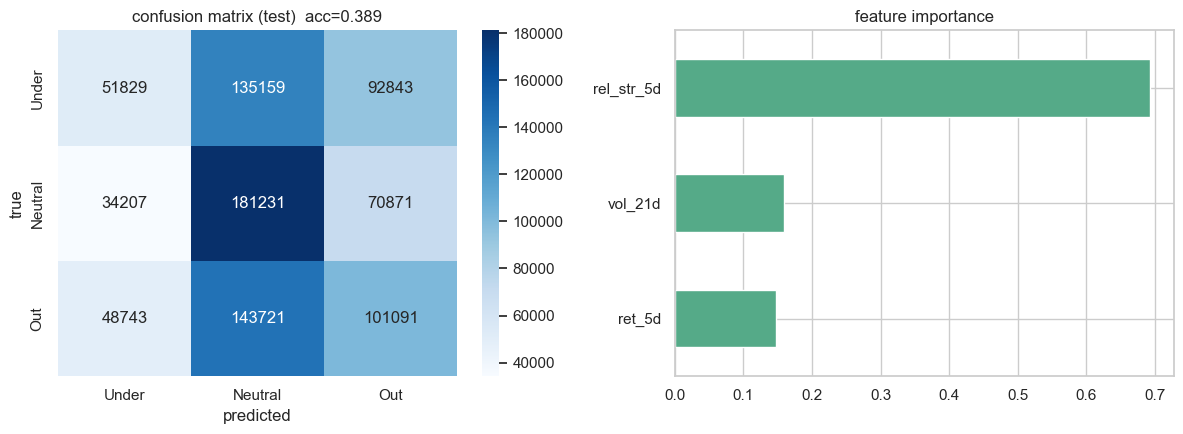

In [9]:
cm = confusion_matrix(yte, pred)
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
sns.heatmap(pd.DataFrame(cm, index=['Under','Neutral','Out'], columns=['Under','Neutral','Out']),
            annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title(f'confusion matrix (test)  acc={acc:.3f}'); ax[0].set_ylabel('true'); ax[0].set_xlabel('predicted')
pd.Series(model.feature_importances_, index=Xcols).sort_values().plot.barh(ax=ax[1], color='#5a8')
ax[1].set_title('feature importance')
plt.tight_layout(); plt.show()

## verdict

In [10]:
edge = (acc - 1/3) * 100
signal = (acc > 0.35) and (mf1 > 0.34)
print('=' * 60)
print(f'accuracy {acc:.3f} vs 0.333 random  ->  {edge:+.1f} points   (purged split, leak-checked below)')
print(f'macro-F1 {mf1:.3f}')
if signal:
    print('VERDICT: there IS a signal (beats random). worth building real features.')
else:
    print('VERDICT: NO clear signal at 5d - about coin-flip. pivot the label to a 21d horizon next.')
print('=' * 60)

accuracy 0.389 vs 0.333 random  ->  +5.5 points   (purged split, leak-checked below)
macro-F1 0.366
VERDICT: there IS a signal (beats random). worth building real features.


## leak checklist (self-verify)

- **(a)** features `ret_5d`, `vol_21d`, `rel_str_5d` all use data <= t (shift / rolling over past). ✓
- **(b)** label uses `price[t+5]` only (the forward window). ✓
- **(c)** split is chronological **and purged**: train drops any row whose forward-5d label window
  would extend past the test start - the last kept train row's label window ends exactly at the
  first test date, zero overlap. ✓ (asserted below)
- **(d)** feature category-mean is trailing (past); label category-mean is the forward window - that
  asymmetry is intended (the label may see the future, features may not). ✓

In [11]:
pos_last_train = prices.index.searchsorted(train['date'].max())
label_end = prices.index[pos_last_train + H]
assert label_end <= test['date'].min(), 'train label window overlaps test - leak!'
print('purge ok: last train label window ends', label_end.date(), '<= first test date', test['date'].min().date())
print('features are all trailing; label is forward. no lookahead in X.')

purge ok: last train label window ends 2024-01-02 <= first test date 2024-01-02
features are all trailing; label is forward. no lookahead in X.
